In [65]:
%matplotlib inline

import sys
import logging
import itertools

import numpy as np
np.random.seed(0)
import gymnasium as gym
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO,
        format='%(asctime)s [%(levelname)s] %(message)s',
        stream=sys.stdout, datefmt='%H:%M:%S')

In [66]:
env = gym.make('Blackjack-v1')
env = env.unwrapped
for key in vars(env):
    logging.info('%s: %s', key, vars(env)[key])
for key in vars(env.spec):
    logging.info('%s: %s', key, vars(env.spec)[key])

19:53:07 [INFO] action_space: Discrete(2)
19:53:07 [INFO] observation_space: Tuple(Discrete(32), Discrete(11), Discrete(2))
19:53:07 [INFO] natural: False
19:53:07 [INFO] sab: True
19:53:07 [INFO] render_mode: None
19:53:07 [INFO] spec: EnvSpec(id='Blackjack-v1', entry_point='gymnasium.envs.toy_text.blackjack:BlackjackEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=False, disable_env_checker=True, kwargs={'sab': True, 'natural': False}, namespace=None, name='Blackjack', version=1, additional_wrappers=(), vector_entry_point=None)
19:53:07 [INFO] id: Blackjack-v1
19:53:07 [INFO] entry_point: gymnasium.envs.toy_text.blackjack:BlackjackEnv
19:53:07 [INFO] reward_threshold: None
19:53:07 [INFO] nondeterministic: False
19:53:07 [INFO] max_episode_steps: None
19:53:07 [INFO] order_enforce: False
19:53:07 [INFO] disable_env_checker: True
19:53:07 [INFO] kwargs: {'sab': True, 'natural': False}
19:53:07 [INFO] additional_wrappers: ()
19:53:07 [INFO] vec

In [67]:
def ob2state(observation):
    return observation[0], observation[1], observation[2]

def play_policy(env, policy=None, verbose=False):
    observation, _ = env.reset()
    reward, terminated, truncated = 0., False, False
    episode_reward, elapsed_steps = 0., 0
    if verbose:
        logging.info('observation = %s', observation)
    while True:
        if verbose:
            logging.info('player = %s, dealer = %s', env.player, env.dealer)
        if policy is None:
            action = env.action_space.sample()
        else:
            state = ob2state(observation)
            action = np.random.choice(env.action_space.n, p=policy[state])
        if verbose:
            logging.info('action = %s', action)
        observation, reward, terminated, truncated, _ = env.step(action)
        if verbose:
            logging.info('observation = %s', observation)
            logging.info('reward = %s', reward)
            logging.info('terminated = %s', terminated)
            logging.info('truncated = %s', truncated)
        episode_reward += reward
        elapsed_steps += 1
        if terminated or truncated:
            break
    return episode_reward, elapsed_steps

episode_reward, elapsed_steps = play_policy(env, verbose=True)
logging.info("episode reward: %.2f", episode_reward)

19:53:07 [INFO] observation = (8, 3, 0)
19:53:07 [INFO] player = [6, 2], dealer = [3, 10]
19:53:07 [INFO] action = 1
19:53:07 [INFO] observation = (18, 3, 0)
19:53:07 [INFO] reward = 0.0
19:53:07 [INFO] terminated = False
19:53:07 [INFO] truncated = False
19:53:07 [INFO] player = [6, 2, 10], dealer = [3, 10]
19:53:07 [INFO] action = 1
19:53:07 [INFO] observation = (23, 3, 0)
19:53:07 [INFO] reward = -1.0
19:53:07 [INFO] terminated = True
19:53:07 [INFO] truncated = False
19:53:07 [INFO] episode reward: -1.00


In [71]:
def evaluate_action_monte_carlo(env, policy, episode_num=500000):
    q = np.zeros_like(policy)  # action value
    c = np.zeros_like(policy)  # count
    for _ in range(episode_num):
        # play an episode
        state_actions = []
        observation, _ = env.reset()
        while True:
            state = ob2state(observation)
            action = np.random.choice(env.action_space.n, p=policy[state])
            state_actions.append((state, action))
            observation, reward, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                break  # end of episode
        g = reward  # return
        for state, action in state_actions:
            c[state][action] += 1.
            q[state][action] += (g - q[state][action]) / c[state][action]
    return q

In [72]:
policy = np.zeros((22, 11, 2, 2))
policy[20:, :, :, 0] = 1  # stand when >=20
policy[:20, :, :, 1] = 1  # hit when <20

q = evaluate_action_monte_carlo(env, policy)  # action value
v = (q * policy).sum(axis=-1)  # state value

19:56:28 [INFO] [[[[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]]


 [[[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+

In [73]:
def plot(data):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    titles = ['without ace', 'with ace']
    have_aces = [0, 1]
    extent = [12, 22, 1, 11]
    for title, have_ace, axis in zip(titles, have_aces, axes):
        dat = data[extent[0]:extent[1], extent[2]:extent[3], have_ace].T
        axis.imshow(dat, extent=extent, origin='lower')
        axis.set_xlabel('player sum')
        axis.set_ylabel('dealer showing')
        axis.set_title(title)

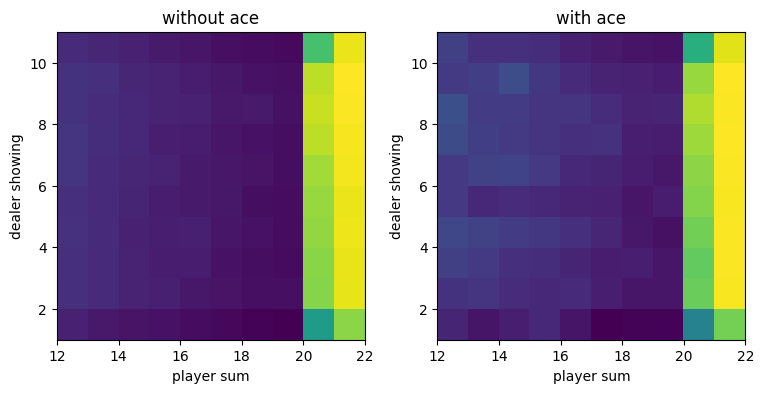

In [75]:
plot(v)